# Chi-Square Distribution

The **Chi-square ($\chi^2$) distribution** is the sum of squares of $\nu$ independent standard normal variables. It is right-skewed for small $\nu$ but approaches Normal as $\nu$ increases. It underlies **goodness-of-fit tests**, **independence tests** in contingency tables, and **confidence intervals for variance**.

| Property | Value |
|---|---|
| **Parameter** | $\nu$ (degrees of freedom, $\nu > 0$) |
| **Support** | $[0, +\infty)$ |
| **Definition** | $\chi^2(\nu) = Z_1^2 + Z_2^2 + \cdots + Z_\nu^2$ where $Z_i \sim N(0,1)$ |
| **Mean** | $\nu$ |
| **Variance** | $2\nu$ |
| **Mode** | $\max(\nu-2, 0)$ |
| **Skewness** | $\sqrt{8/\nu}$ — decreases as $\nu \uparrow$ |
| **Relationship** | $\chi^2(\nu) = \text{Gamma}(\nu/2, 2)$;  $\chi^2(2) = \text{Exponential}(2)$ |
| **Primary use** | Goodness-of-fit, contingency table independence, CI for $\sigma^2$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Chi-Square Distribution

### Panel 1 — PDF: Varying Degrees of Freedom
Each curve shows the **PDF** of $\chi^2(\nu)$ for increasing $\nu$. At small $\nu$ the distribution is strongly right-skewed with a mode near 0; as $\nu$ grows it shifts right, broadens, and approaches a symmetric Normal shape.

### Panel 2 — $\chi^2(\nu)$ as Sum of Squared Normals
Histograms of simulated $\chi^2(\nu)$ values (obtained by summing $\nu$ squared standard normals) are overlaid with the theoretical PDF, confirming the relationship $\chi^2(\nu) = Z_1^2 + \cdots + Z_\nu^2$.

### Panel 3 — Goodness-of-Fit Test: Fair Die?
The $\chi^2(5)$ null distribution is shown with the $\alpha=0.05$ rejection region (red). The orange vertical line is the observed test statistic $\chi^2 = \sum(O_i - E_i)^2/E_i$ for a dice-roll experiment. The p-value indicates whether the die is fair.


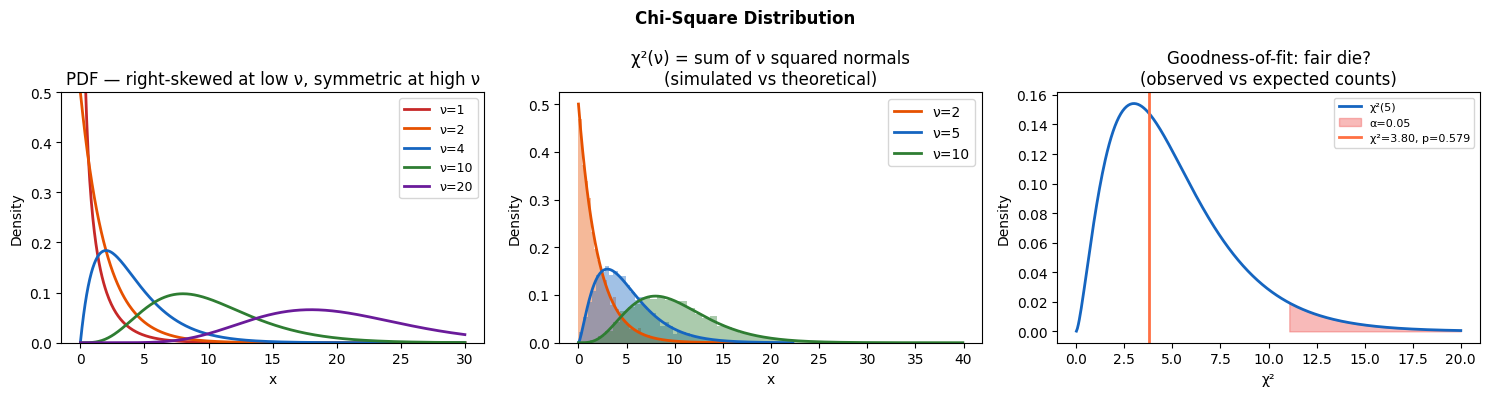

Dice GOF test: χ²=3.800, df=5, p=0.5786
Observed: [18 22 15 25 17 23], Expected: [20 20 20 20 20 20]


In [2]:
x = np.linspace(0.01, 30, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chi-Square Distribution', fontsize=12, fontweight='bold')

# PDF — varying df
for df, color, label in [(1,  '#C62828', 'ν=1'),
                          (2,  '#E65100', 'ν=2'),
                          (4,  '#1565C0', 'ν=4'),
                          (10, '#2E7D32', 'ν=10'),
                          (20, '#6A1B9A', 'ν=20')]:
    axes[0].plot(x, stats.chi2(df).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed at low ν, symmetric at high ν')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=9)

# χ² as sum of squared normals
np.random.seed(42)
n_sim = 5000
for df, color, label in [(2, '#E65100', 'ν=2'), (5, '#1565C0', 'ν=5'), (10, '#2E7D32', 'ν=10')]:
    simulated = np.sum(np.random.normal(0, 1, (n_sim, df))**2, axis=1)
    axes[1].hist(simulated, bins=50, density=True, alpha=0.4, color=color)
    x_plot = np.linspace(0, simulated.max(), 300)
    axes[1].plot(x_plot, stats.chi2(df).pdf(x_plot), color=color, linewidth=2, label=label)
axes[1].set_title('χ²(ν) = sum of ν squared normals\n(simulated vs theoretical)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# Goodness-of-fit test (dice fairness)
observed = np.array([18, 22, 15, 25, 17, 23])  # 120 rolls
expected = np.full(6, 20.0)  # fair die: 20 per face
chi2_stat, p_val = stats.chisquare(observed, expected)
df_gof = len(observed) - 1
x_chi = np.linspace(0.01, 20, 400)
axes[2].plot(x_chi, stats.chi2(df_gof).pdf(x_chi),
             color='#1565C0', linewidth=2, label=f'χ²({df_gof})')
x_crit = stats.chi2(df_gof).ppf(0.95)
axes[2].fill_between(x_chi, stats.chi2(df_gof).pdf(x_chi),
                     where=(x_chi >= x_crit),
                     color='#EF5350', alpha=0.4, label=f'α=0.05')
axes[2].axvline(chi2_stat, color='#FF7043', linewidth=2,
                label=f'χ²={chi2_stat:.2f}, p={p_val:.3f}')
axes[2].set_title('Goodness-of-fit: fair die?\n(observed vs expected counts)')
axes[2].set_xlabel('χ²'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Dice GOF test: χ²={chi2_stat:.3f}, df={df_gof}, p={p_val:.4f}")
print(f"Observed: {observed}, Expected: {expected.astype(int)}")

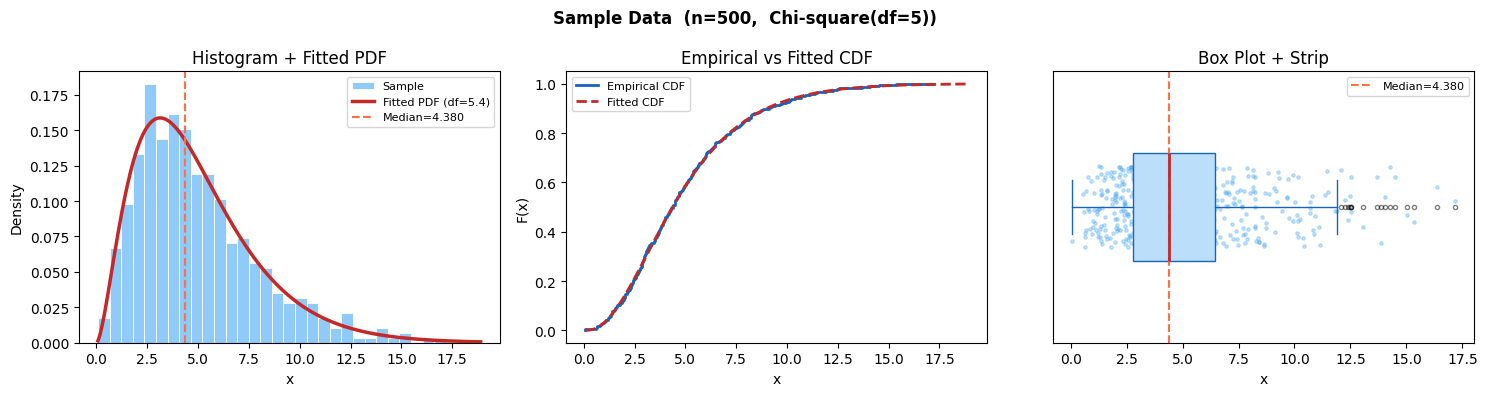

n=500  mean=4.9652  median=4.3798  std=3.0019  skew=1.1037  kurtosis=1.2599


In [3]:
# Sample data plots — Chi-square(df=5)
np.random.seed(42)
sample_d = stats.chi2.rvs(df=5, size=500)
df_hat, loc_hat, scale_hat = stats.chi2.fit(sample_d, floc=0)
x_fit = np.linspace(sample_d.min() * 0.9, sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Chi-square(df=5))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.chi2(df_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (df={df_hat:.1f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.chi2(df_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Definition** | $\chi^2(\nu) = Z_1^2 + \cdots + Z_\nu^2$ — sum of squared standard normals |
| **Shape** | Strongly right-skewed at low $\nu$; approaches Normal as $\nu \to \infty$ |
| **Goodness-of-fit** | $\chi^2 = \sum (O_i - E_i)^2/E_i$; df = categories $- 1 -$ estimated params |
| **Independence test** | Contingency table: df $= (\text{rows}-1)(\text{cols}-1)$ |
| **Variance CI** | $\left(\dfrac{(n-1)s^2}{\chi^2_{\alpha/2}},\; \dfrac{(n-1)s^2}{\chi^2_{1-\alpha/2}}\right)$ — CI for population $\sigma^2$ |
| **Additive** | $\chi^2(\nu_1) + \chi^2(\nu_2) = \chi^2(\nu_1+\nu_2)$ — degrees of freedom add |
| **Relationship** | Special case of Gamma: $\chi^2(\nu) = \text{Gamma}(\nu/2,\; 2)$ |
